In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error

In [2]:
if torch.xpu.is_available():
    device = torch.device("xpu")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("The device:", device)

if device.type == "xpu":
    print("GPU:", torch.xpu.get_device_name(0))
    print("XPU Count:", torch.xpu.device_count())

The device: xpu
GPU: Intel(R) Arc(TM) 130V GPU (16GB)
XPU Count: 1


In [3]:
ticker = 'AAPL'
df = yf.download(ticker, '2020-01-01')

[*********************100%***********************]  1 of 1 completed


<Axes: xlabel='Date'>

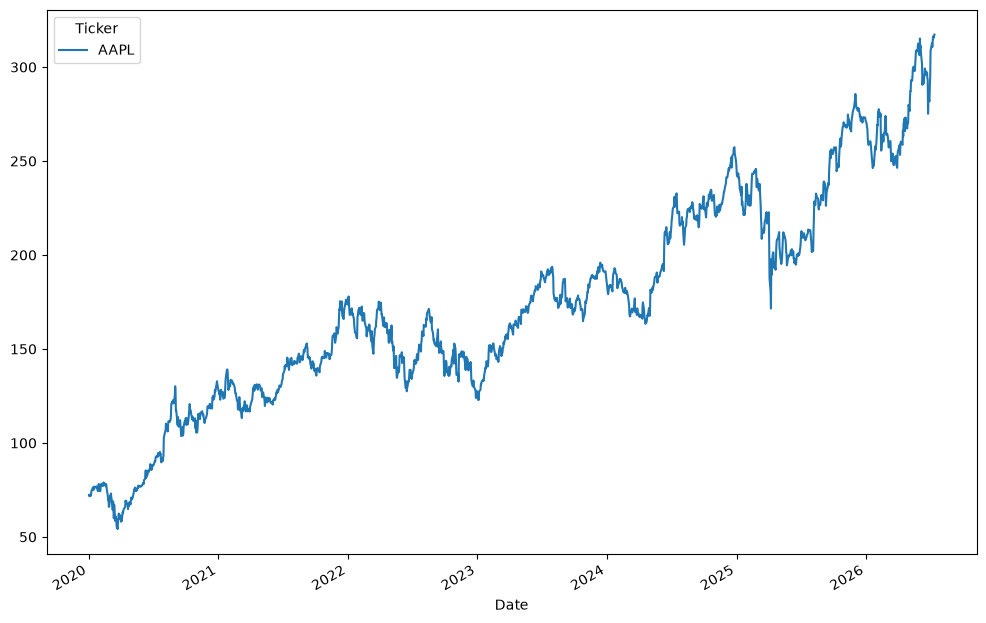

In [4]:
df.Close.plot(figsize=(12,8))

In [5]:
scaler = StandardScaler()

df[['Close']] = scaler.fit_transform(df[['Close']])

In [6]:
df.Close

Ticker,AAPL
Date,
2020-01-02,-1.788094
2020-01-03,-1.800526
2020-01-06,-1.790435
2020-01-07,-1.796438
2020-01-08,-1.776003
...,...
2026-07-07,2.424916
2026-07-08,2.473176
2026-07-09,2.523203


In [7]:
seq_length = 30
data = []

for i in range(len(df) - seq_length):
    data.append(df.Close[i:i+seq_length])

data = np.array(data)

In [9]:
train_size = int(0.8 * len(data))

X_train = torch.from_numpy(data[:train_size, :-1, :]).type(torch.Tensor).to(device)
y_train = torch.from_numpy(data[:train_size, -1, :]).type(torch.Tensor).to(device)
X_test = torch.from_numpy(data[train_size:, :-1, :]).type(torch.Tensor).to(device)
y_test = torch.from_numpy(data[train_size:, -1, :]).type(torch.Tensor).to(device)

In [10]:
class PredictionModel(nn.Module):

    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(PredictionModel, self).__init__()

        self.num_layers = num_layers
        self.hidden_dim = hidden_dim

        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=device)

        out, (hn, cn) = self.lstm(x, (h0.detach(), c0.detach()))
        out = self.fc(out[:, -1, :])

        return out

In [11]:
model = PredictionModel(input_dim=1, hidden_dim=32, num_layers=2, output_dim=1).to(device)

In [12]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [13]:
num_epochs = 200

model.train()

for epoch in range(num_epochs):
    optimizer.zero_grad()

    train_pred_tensor = model(X_train)
    loss = criterion(train_pred_tensor, y_train)

    loss.backward()
    optimizer.step()

    if epoch % 25 == 0:
        print(epoch, loss.item())

0 0.6376757025718689
25 0.012596040032804012
50 0.004779967479407787
75 0.004029016010463238
100 0.003707429626956582
125 0.003474160097539425
150 0.0032639107666909695
175 0.003067601704970002


In [14]:
model.eval()

with torch.no_grad():
    train_pred_tensor = model(X_train)
    test_pred_tensor = model(X_test)

train_pred = scaler.inverse_transform(
    train_pred_tensor.cpu().numpy()
)

train_actual = scaler.inverse_transform(
    y_train.cpu().numpy()
)

test_pred = scaler.inverse_transform(
    test_pred_tensor.cpu().numpy()
)

test_actual = scaler.inverse_transform(
    y_test.cpu().numpy()
)

In [15]:
train_rmse = root_mean_squared_error(
    train_actual[:, 0],
    train_pred[:, 0]
)

test_rmse = root_mean_squared_error(
    test_actual[:, 0],
    test_pred[:, 0]
)

print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")

Train RMSE: 3.0393
Test RMSE: 8.0562
